In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
import io 
import numpy as np


In [8]:
PROJECT_ROOT = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab"

FEATURES_PATH = os.path.join(PROJECT_ROOT, 'analysis', 'unsupervised_approach', 'c1c3000_features_extended_with_clusters.csv')

features_df = pd.read_csv(FEATURES_PATH)


In [10]:
y = features_df['kmeans_cluster']
cols_to_drop = ['unique_id', 'label', 'kmeans_cluster', 'spectral_cluster']
X = features_df.drop(columns=cols_to_drop)

In [11]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y, shuffle=True)

print(f"Data prepared: {X_train.shape[0]} training samples and {X_test.shape[0]} testing samples.")


Data prepared: 112 training samples and 49 testing samples.


In [12]:
# --- 3. Train Random Forest Classifier ---
# Initialize the classifier with settings for reproducibility and performance
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True, n_jobs=-1)

# Train the model
rf_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest Classifier Accuracy: {accuracy:.4f}")
print(f"Out-of-Bag Score: {rf_classifier.oob_score_:.4f}")



Random Forest Classifier Accuracy: 0.9388
Out-of-Bag Score: 0.8839


In [13]:
# --- 4. Get and Display Feature Importances ---
importances: list[float] = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n--- Feature Importances for Predicting K-Means Clusters ---")
print(feature_importance_df)


--- Feature Importances for Predicting K-Means Clusters ---
                       feature  importance
17               cell_height_y    0.092096
12               intensity_std    0.086275
9            minor_axis_length    0.084198
5                max_intensity    0.079303
0                         area    0.068760
11                 circularity    0.066056
1                    perimeter    0.064250
4               mean_intensity    0.055636
8            major_axis_length    0.044399
16            glcm_correlation    0.040745
15                 glcm_energy    0.038739
13               glcm_contrast    0.037047
2                     solidity    0.036013
3                       extent    0.033204
21  chromocenter_area_fraction    0.029017
7                 eccentricity    0.026344
14            glcm_homogeneity    0.026212
18    mean_dist_to_5_neighbors    0.025364
19             n_chromocenters    0.022242
20      mean_chromocenter_area    0.019974
6                min_intensity    0.

C:\Users\shiva\AppData\Local\Temp\ipykernel_21200\4173930689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


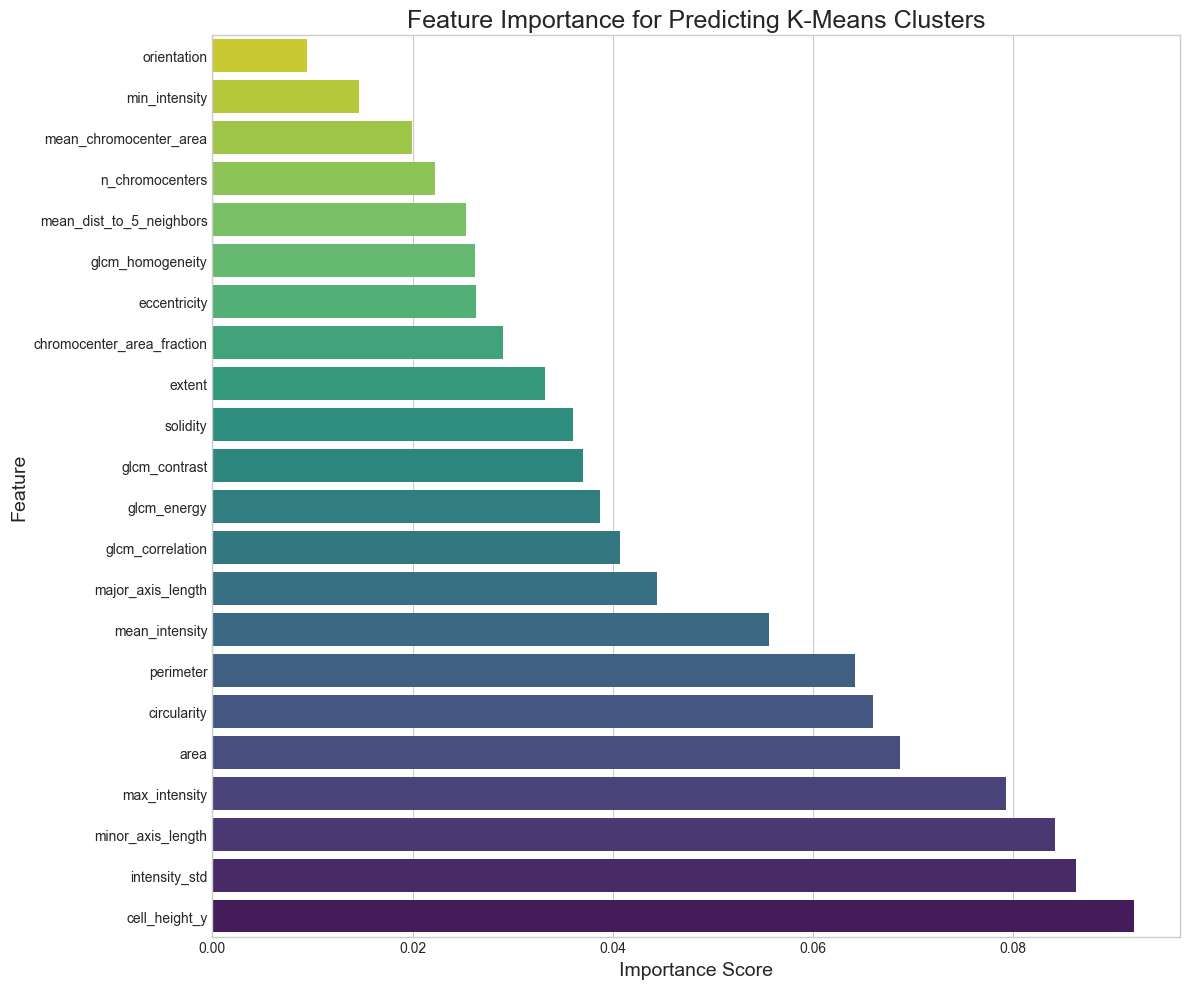

In [14]:
# --- 5. Plot Feature Importances ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Predicting K-Means Clusters', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.gca().invert_yaxis() # Display the most important feature at the top
plt.tight_layout()
plt.show()

